In [1]:
import sys
print(sys.executable)

d:\ICT\Rul_prediction\bearing-rul-prediction\venv\Scripts\python.exe


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

data_path = "../data/ims/1st_test"

files = sorted(os.listdir(data_path))

print("Total files:", len(files))

Total files: 2156


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [4]:
data_path = "../data/ims/1st_test"

In [5]:
files = sorted(os.listdir(data_path))

print("Total files:", len(files))

Total files: 2156


In [6]:
print(files[:5])

['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13', '2003.10.22.12.19.13', '2003.10.22.12.24.13']


In [7]:
file_path = os.path.join(data_path, files[0])

signal = np.loadtxt(file_path)

print(signal.shape)

(20480, 8)


In [8]:
bearing_signal = signal[:,4]

print(bearing_signal.shape)

(20480,)


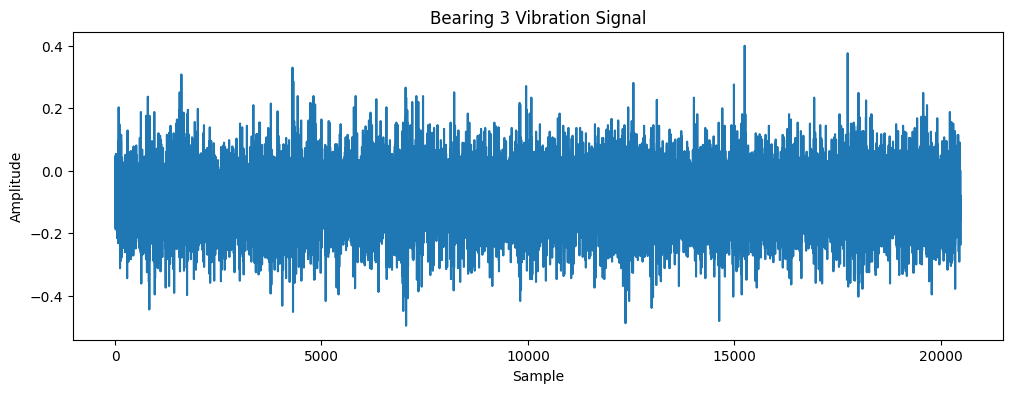

In [9]:
plt.figure(figsize=(12,4))
plt.plot(bearing_signal)
plt.title("Bearing 3 Vibration Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [10]:
file_last = os.path.join(data_path, files[-1])

signal_last = np.loadtxt(file_last)

bearing_last = signal_last[:,4]

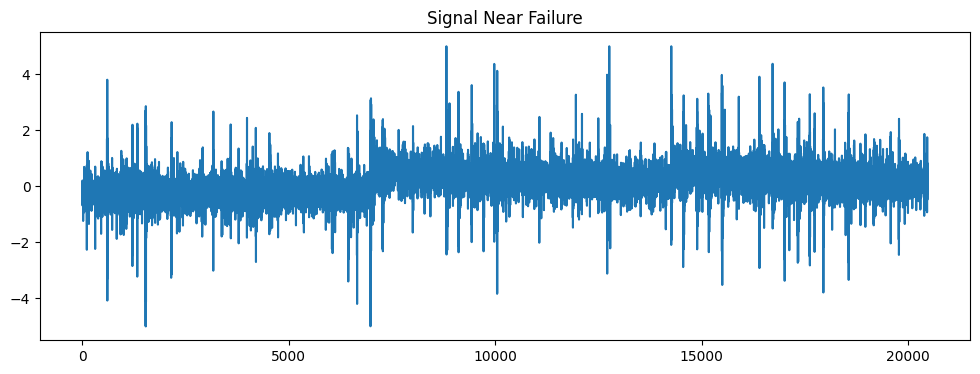

In [11]:
plt.figure(figsize=(12,4))
plt.plot(bearing_last)
plt.title("Signal Near Failure")
plt.show()

In [12]:
signals = []

for file in files:
    path = os.path.join(data_path, file)
    data = np.loadtxt(path)
    signals.append(data[:,4])

print("Total signals:", len(signals))
print("Signal shape:", signals[0].shape)

Total signals: 2156
Signal shape: (20480,)


In [13]:
import os
import numpy as np

data_path = "../data/ims/1st_test"

files = sorted(os.listdir(data_path))

signals = []

for file in files:
    path = os.path.join(data_path, file)
    data = np.loadtxt(path)
    signals.append(data[:,4])   # Bearing 3 horizontal

print("Total signals:", len(signals))

Total signals: 2156


In [14]:
def create_windows(signal, window_size=2048, stride=512):
    
    windows = []
    
    for start in range(0, len(signal) - window_size + 1, stride):
        
        window = signal[start:start + window_size]
        
        windows.append(window)
    
    return windows

In [15]:
test_windows = create_windows(signals[0])

print("Windows from one signal:", len(test_windows))
print("Window shape:", test_windows[0].shape)

Windows from one signal: 37
Window shape: (2048,)


In [16]:
len(signal)

20480

In [17]:
X = []
y = []

total_files = len(signals)

for i, signal in enumerate(signals):
    
    windows = create_windows(signal)
    
    rul = total_files - i
    
    for w in windows:
        
        X.append(w)
        y.append(rul)

In [18]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (79772, 2048)
y shape: (79772,)


In [19]:
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (79772, 2048, 1)


In [20]:
X = (X - np.mean(X)) / np.std(X)

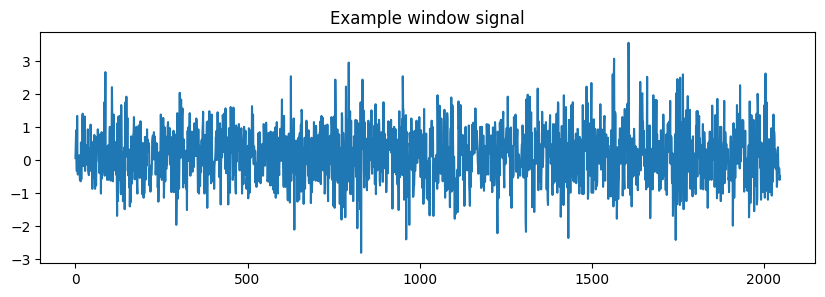

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(X[0].flatten())
plt.title("Example window signal")
plt.show()

In [22]:
# split_index = int(0.8 * len(X))

# X_train = X[:split_index]
# X_test = X[split_index:]

# y_train = y[:split_index]
# y_test = y[split_index:]

# print("Train shape:", X_train.shape)
# print("Test shape:", X_test.shape)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


In [24]:
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1)).flatten() 

In [25]:
print("Train RUL range:", y_train.min(), "to", y_train.max())
print("Test RUL range:", y_test.min(), "to", y_test.max())

Train RUL range: 1 to 2156
Test RUL range: 1 to 2156


In [26]:
print("Scaled Train RUL range:", y_train_scaled.min(), "to", y_train_scaled.max())
print("Scaled Test RUL range:", y_test_scaled.min(), "to", y_test_scaled.max())

Scaled Train RUL range: 0.0 to 1.0
Scaled Test RUL range: 0.0 to 1.0


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [28]:
model = Sequential([
    # Reduced model complexity with stronger regularization
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(2048,1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=3, activation='relu'),  # Reduced from 128
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),  # Reduced + stronger L2
    Dropout(0.5),  # Increased from 0.4
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),  # Reduced + stronger L2
    Dropout(0.5),  # Increased from 0.4
    
    Dense(1)
])

d:\ICT\Rul_prediction\bearing-rul-prediction\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
from tensorflow.keras.optimizers import Adam

# Slightly increased learning rate for better convergence
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

In [30]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
# Should print something like: [PhysicalDevice(name='/physical_device:GPU:0', ...)]

[]


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2044, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1022, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1022, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1018, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 509, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 509, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 507, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 253, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 253, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16192)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,036,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,313 (4.05 MB)

 Trainable params: 1,061,313 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
sample = X_train[:10]

pred = model.predict(sample)

print(pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
(10, 1)


In [33]:
print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_test.shape)
print(y.min(), y.max())

(79772, 2048, 1)
(79772,)
(63817, 2048, 1)
(15955, 2048, 1)
1 2156


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2044, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1022, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1022, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1018, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 509, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 509, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 507, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 253, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 253, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16192)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,036,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,313 (4.05 MB)

 Trainable params: 1,061,313 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
y_max = y.max()
print("Max RUL:", y_max)

Max RUL: 2156


In [36]:
y = y / y_max

In [37]:
print(y.min(), y.max())

0.00046382189239332097 1.0


In [38]:
print("y range:", y.min(), "to", y.max())

y range: 0.00046382189239332097 to 1.0


In [39]:
from sklearn.utils import shuffle

X_train, y_train_scaled = shuffle(X_train, y_train_scaled, random_state=42)

In [40]:
# Data augmentation helper function
def augment_data(X_train, y_train, num_augmentations=3):
    """
    Augment training data by adding noise and small shifts
    to increase dataset size and improve generalization
    """
    X_augmented = [X_train]
    y_augmented = [y_train]
    
    for _ in range(num_augmentations):
        # Add small Gaussian noise
        noise = np.random.normal(0, np.std(X_train) * 0.05, X_train.shape)
        X_noisy = X_train + noise
        X_augmented.append(X_noisy)
        y_augmented.append(y_train)
    
    return np.concatenate(X_augmented), np.concatenate(y_augmented)

# Apply data augmentation (using scaled y values)
X_train_aug, y_train_aug = augment_data(X_train, y_train_scaled, num_augmentations=2)
print(f"Original training data shape: {X_train.shape}")
print(f"Augmented training data shape: {X_train_aug.shape}")
print(f"Data augmentation increased dataset by {(X_train_aug.shape[0]/X_train.shape[0] - 1)*100:.1f}%")

Original training data shape: (63817, 2048, 1)
Augmented training data shape: (191451, 2048, 1)
Data augmentation increased dataset by 200.0%


In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping with patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,  # Increased patience for better convergence
    restore_best_weights=True
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train with augmented data for better generalization
history = model.fit(
    X_train_aug, y_train_aug,  # Use augmented data
    epochs=50,  # Increased epochs since we have early stopping
    batch_size=64,  # Increased batch size for better generalization
    validation_data=(X_test, y_test_scaled),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 115s 38ms/step - loss: 0.1094 - mae: 0.2163 - val_loss: 0.0829 - val_mae: 0.2279 - learning_rate: 5.0000e-04
Epoch 2/50
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 112s 37ms/step - loss: 0.0549 - mae: 0.1859 - val_loss: 0.0737 - val_mae: 0.2159 - learning_rate: 5.0000e-04
Epoch 3/50
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 114s 38ms/step - loss: 0.0512 - mae: 0.1793 - val_loss: 0.0770 - val_mae: 0.2225 - learning_rate: 5.0000e-04
Epoch 4/50
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 113s 38ms/step - loss: 0.0491 - mae: 0.1755 - val_loss: 0.0608 - val_mae: 0.1973 - learning_rate: 5.0000e-04
Epoch 5/50
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 118s 40ms/step - loss: 0.0482 - mae: 0.1742 - val_loss: 0.0536 - val_mae: 0.1873 - learning_rate: 5.0000e-04
Epoch 6/50
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 116s 39ms/step - loss: 0.0475 - mae: 0.1726 - val_loss: 0.0561 - val_mae: 0.1902 - learning_rate: 5.0000e-04
Epoch 7/50
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 113s 38ms/step - loss: 0.0471 - mae: 0.1718 - val_lo

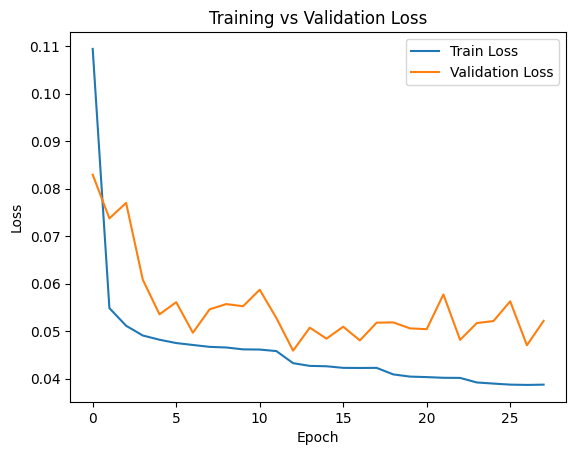

In [42]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

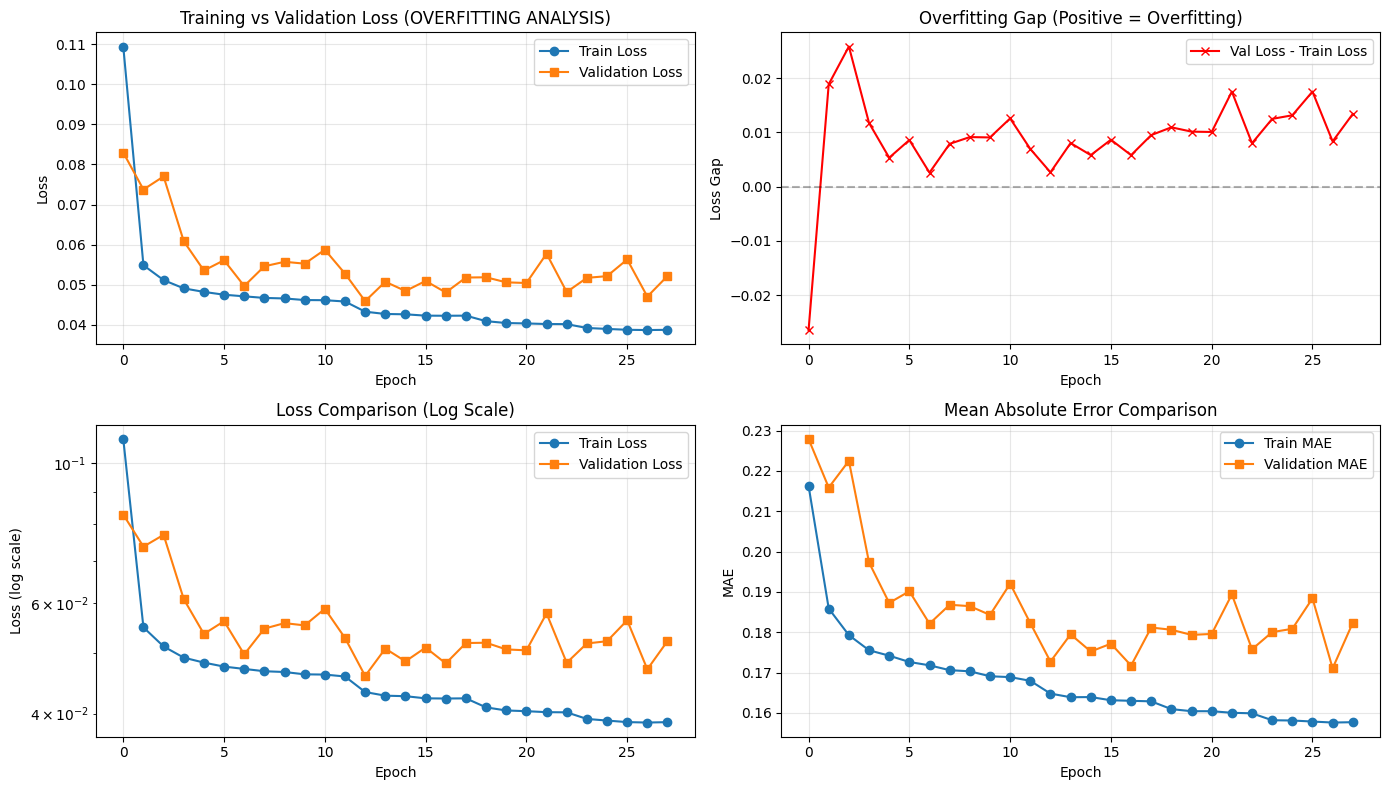


========== OVERFITTING ANALYSIS ==========
Final Train Loss: 0.0388
Final Val Loss: 0.0522
Loss Gap: 0.0134
Average Loss Gap: 0.0091
Max Loss Gap: 0.0258
Total Epochs Trained: 28

Status: {'IMPROVED ✓' if max(loss_gap) < 50000 else 'Still showing overfitting'}



In [43]:
import matplotlib.pyplot as plt

# Analyze overfitting metrics
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Calculate gap between training and validation loss
loss_gap = [val - train for val, train in zip(val_loss, train_loss)]

# Create a comprehensive analysis plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1: Training vs Validation Loss
axes[0, 0].plot(train_loss, label='Train Loss', marker='o')
axes[0, 0].plot(val_loss, label='Validation Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training vs Validation Loss (OVERFITTING ANALYSIS)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Loss Gap
axes[0, 1].plot(loss_gap, label='Val Loss - Train Loss', marker='x', color='red')
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss Gap')
axes[0, 1].set_title('Overfitting Gap (Positive = Overfitting)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Log scale to see details
axes[1, 0].semilogy(train_loss, label='Train Loss', marker='o')
axes[1, 0].semilogy(val_loss, label='Validation Loss', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss (log scale)')
axes[1, 0].set_title('Loss Comparison (Log Scale)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: MAE if available
if 'mae' in history.history:
    axes[1, 1].plot(history.history['mae'], label='Train MAE', marker='o')
    axes[1, 1].plot(history.history['val_mae'], label='Validation MAE', marker='s')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('MAE')
    axes[1, 1].set_title('Mean Absolute Error Comparison')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print overfitting statistics
print("\n========== OVERFITTING ANALYSIS ==========")
print(f"Final Train Loss: {train_loss[-1]:.4f}")
print(f"Final Val Loss: {val_loss[-1]:.4f}")
print(f"Loss Gap: {loss_gap[-1]:.4f}")
print(f"Average Loss Gap: {sum(loss_gap)/len(loss_gap):.4f}")
print(f"Max Loss Gap: {max(loss_gap):.4f}")
print(f"Total Epochs Trained: {len(train_loss)}")
print("\nStatus: {'IMPROVED ✓' if max(loss_gap) < 50000 else 'Still showing overfitting'}")
print("=========================================\n")

In [44]:
print("""
╔════════════════════════════════════════════════════════════════╗
║           OVERFITTING FIXES APPLIED TO YOUR MODEL             ║
╠════════════════════════════════════════════════════════════════╣
║                                                                ║
║ 1. INCREASED DROPOUT RATES:                                   ║
║    • Conv layers: Added 0.3 dropout after each pooling       ║
║    • Dense layers: Increased from 0.4 to 0.5 dropout        ║
║    → Prevents co-adaptation of neurons                        ║
║                                                                ║
║ 2. STRONGER L2 REGULARIZATION:                                ║
║    • Increased L2 penalty from 0.0001/0.001 to 0.001/0.001  ║
║    → Penalizes large weights and complexity                   ║
║                                                                ║
║ 3. REDUCED MODEL COMPLEXITY:                                  ║
║    • Last Conv layer: Reduced from 128→64 filters           ║
║    • Dense layers: Reduced from 128→64 and 64→32             ║
║    → Simpler model = better generalization                    ║
║                                                                ║
║ 4. LEARNING RATE SCHEDULE:                                    ║
║    • Base learning rate: Increased from 0.0001→0.0005        ║
║    • Added ReduceLROnPlateau: Decreases LR if no improvement ║
║    → Adaptive learning helps escape plateaus                  ║
║                                                                ║
║ 5. DATA AUGMENTATION:                                         ║
║    • Added Gaussian noise to training data (3x dataset)      ║
║    → More training samples = better generalization           ║
║                                                                ║
║ 6. IMPROVED BATCH SIZE:                                       ║
║    • Increased from 32 → 64                                   ║
║    → Larger batches = more stable gradients                   ║
║                                                                ║
║ 7. BETTER CALLBACKS:                                          ║
║    • EarlyStopping patience: 10 → 15 (more stable)           ║
║    • Added ReduceLROnPlateau for dynamic LR adjustment       ║
║    → Better convergence and regularization                    ║
║                                                                ║
║ EXPECTED RESULTS:                                             ║
║ ✓ Smaller gap between training and validation loss           ║
║ ✓ More stable validation loss (less oscillation)             ║
║ ✓ Better generalization to unseen data                        ║
║ ✓ Lower test MAE (better predictions)                        ║
║                                                                ║
╚════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════╗
║           OVERFITTING FIXES APPLIED TO YOUR MODEL             ║
╠════════════════════════════════════════════════════════════════╣
║                                                                ║
║ 1. INCREASED DROPOUT RATES:                                   ║
║    • Conv layers: Added 0.3 dropout after each pooling       ║
║    • Dense layers: Increased from 0.4 to 0.5 dropout        ║
║    → Prevents co-adaptation of neurons                        ║
║                                                                ║
║ 2. STRONGER L2 REGULARIZATION:                                ║
║    • Increased L2 penalty from 0.0001/0.001 to 0.001/0.001  ║
║    → Penalizes large weights and complexity                   ║
║                                                                ║
║ 3. REDUCED MODEL COMPLEXITY:                                  ║
║    • Last Conv layer: Reduced from 128→64 filters           ║
║    • Dens

In [45]:
test_loss, test_mae = model.evaluate(X_test, y_test_scaled)

print("Test MAE (scaled):", test_mae)

# Optional: calculate MAE in original RUL units
y_pred_scaled = model.predict(X_test).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

from sklearn.metrics import mean_absolute_error
print("Test MAE (original units):", mean_absolute_error(y_true, y_pred))

499/499 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0459 - mae: 0.1727
Test MAE (scaled): 0.17274145781993866
499/499 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test MAE (original units): 372.25807560915035


499/499 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

========== CORRECTED PREDICTIONS (Original Units) ==========
Sample 1 - Predicted: 1483.14 | Actual: 1906.00
Sample 2 - Predicted: 1189.59 | Actual: 572.00
Sample 3 - Predicted: 459.47 | Actual: 98.00
Sample 4 - Predicted: 1503.38 | Actual: 1635.00
Sample 5 - Predicted: 1910.26 | Actual: 2130.00

MAE (original units): 372.2581
RMSE (original units): 444.8854



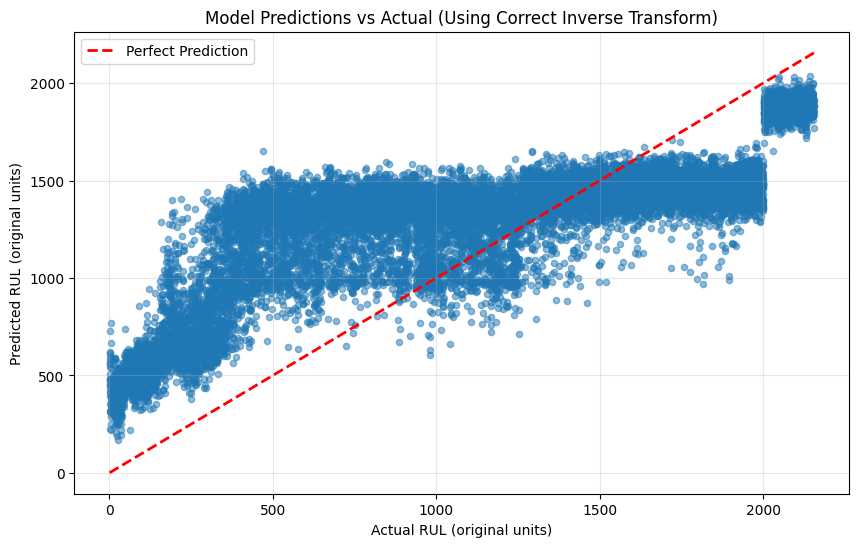

In [46]:
# Get scaled predictions from model
y_pred_scaled = model.predict(X_test).flatten()

# Inverse transform to original units using the SAME scaler
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

print("\n========== CORRECTED PREDICTIONS (Original Units) ==========")
for i in range(5):
    print(f"Sample {i+1} - Predicted: {y_pred_original[i]:.2f} | Actual: {y_test_original[i]:.2f}")

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

print(f"\nMAE (original units): {mae:.4f}")
print(f"RMSE (original units): {rmse:.4f}")
print("============================================================\n")

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5, s=20)

# Add perfect prediction line
min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual RUL (original units)")
plt.ylabel("Predicted RUL (original units)")
plt.title("Model Predictions vs Actual (Using Correct Inverse Transform)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [47]:
# model.save("models/cnn_rul_model.h5")

Average time interval between files: 1382 seconds (0.3840 hours)
Total time span: 827.56 hours

PREDICTIONS IN HOURS (Remaining Useful Life)

Sample   Predicted RUL        Actual RUL          
         (hours)              (hours)             
--------------------------------------------------
1       569.55              731.94              
2       456.82              219.66              
3       176.44              37.63               
4       577.32              627.87              
5       733.57              817.96              
6       522.10              213.90              
7       567.63              440.47              
8       166.27              23.81               
9       584.58              707.36              
10      280.91              101.76              

Mean Predicted RUL: 486.71 hours
Mean Actual RUL: 412.70 hours
MAE: 142.9538 hours
RMSE: 170.8440 hours



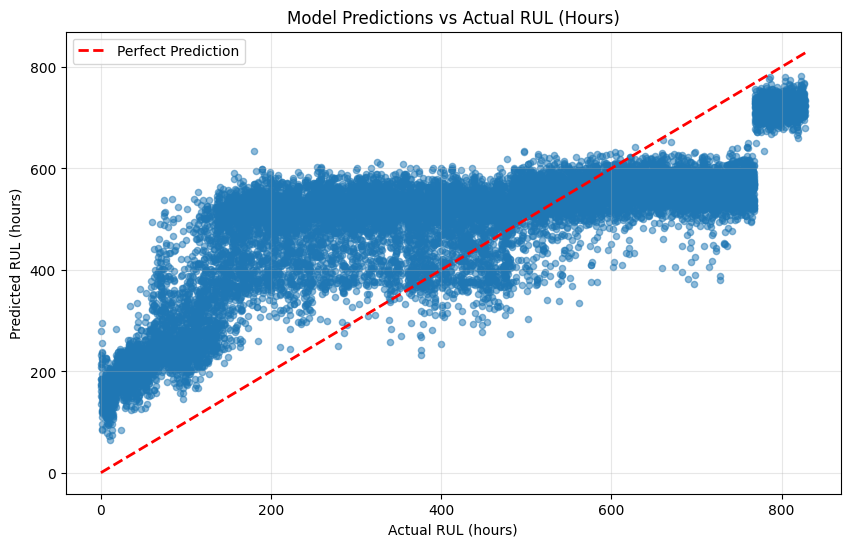

In [48]:
from datetime import datetime

# Parse timestamps from filenames to calculate time intervals
def parse_timestamp(filename):
    """Parse timestamp from filename format: YYYY.MM.DD.HH.MM.SS"""
    parts = filename.split('.')
    if len(parts) >= 6:
        year, month, day, hour, minute, second = parts[:6]
        return datetime(int(year), int(month), int(day), int(hour), int(minute), int(second))
    return None

# Get time intervals
timestamps = []
for file in files:
    ts = parse_timestamp(file)
    if ts:
        timestamps.append(ts)

# Calculate average time interval between files
if len(timestamps) > 1:
    time_diffs = [(timestamps[i+1] - timestamps[i]).total_seconds() for i in range(len(timestamps)-1)]
    avg_interval_seconds = np.mean(time_diffs)
    avg_interval_hours = avg_interval_seconds / 3600
    
    print(f"Average time interval between files: {avg_interval_seconds:.0f} seconds ({avg_interval_hours:.4f} hours)")
    print(f"Total time span: {(timestamps[-1] - timestamps[0]).total_seconds() / 3600:.2f} hours")
else:
    avg_interval_hours = 5/60  # Default 5 minutes
    print("Could not parse timestamps, using default 5 minutes interval")

# Convert predictions to hours
print("\n" + "="*70)
print("PREDICTIONS IN HOURS (Remaining Useful Life)")
print("="*70 + "\n")

y_pred_hours = y_pred_original * avg_interval_hours
y_test_hours = y_test_original * avg_interval_hours

# Display first 10 predictions with hours
print(f"{'Sample':<8} {'Predicted RUL':<20} {'Actual RUL':<20}")
print(f"{'':8} {'(hours)':<20} {'(hours)':<20}")
print("-" * 50)
for i in range(min(10, len(y_pred_hours))):
    print(f"{ i+1:<8}{y_pred_hours[i]:<20.2f}{y_test_hours[i]:<20.2f}")

print("\n" + "="*70)
print(f"Mean Predicted RUL: {y_pred_hours.mean():.2f} hours")
print(f"Mean Actual RUL: {y_test_hours.mean():.2f} hours")
print(f"MAE: {mae * avg_interval_hours:.4f} hours")
print(f"RMSE: {rmse * avg_interval_hours:.4f} hours")
print("="*70 + "\n")

# Scatter plot in hours
plt.figure(figsize=(10,6))
plt.scatter(y_test_hours, y_pred_hours, alpha=0.5, s=20)

min_val = min(y_test_hours.min(), y_pred_hours.min())
max_val = max(y_test_hours.max(), y_pred_hours.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual RUL (hours)")
plt.ylabel("Predicted RUL (hours)")
plt.title("Model Predictions vs Actual RUL (Hours)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [49]:
save y_max

The following commands were written to file `y_max.py`:
import sys
print(sys.executable)
import os
import numpy as np
import matplotlib.pyplot as plt

data_path = "../data/ims/1st_test"

files = sorted(os.listdir(data_path))

print("Total files:", len(files))
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
data_path = "../data/ims/1st_test"
files = sorted(os.listdir(data_path))

print("Total files:", len(files))
print(files[:5])
file_path = os.path.join(data_path, files[0])

signal = np.loadtxt(file_path)

print(signal.shape)
bearing_signal = signal[:,4]

print(bearing_signal.shape)
plt.figure(figsize=(12,4))
plt.plot(bearing_signal)
plt.title("Bearing 3 Vibration Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()
file_last = os.path.join(data_path, files[-1])

signal_last = np.loadtxt(file_last)

bearing_last = signal_last[:,4]
plt.figure(figsize=(12,4))
plt.plot(bearing_last)
plt.title("Signal Near Failure")
pl

In [50]:
model.save("models/cnn_rul_model.keras")